In [1]:
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_csv('letterdata.csv')

In [3]:
df

,letter,xbox,ybox,width,height,onpix,xbar,ybar,x2bar,y2bar,xybar,x2ybar,xy2bar,xedge,xedgey,yedge,yedgex
0,T,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
1,I,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
2,D,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
3,N,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
4,G,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,D,2,2,3,3,2,7,7,7,6,6,6,4,2,8,3,7
19996,C,7,10,8,8,4,4,8,6,9,12,9,13,2,9,3,7
19997,T,6,9,6,7,5,6,11,3,7,11,9,5,2,12,2,4
19998,S,2,3,4,2,1,8,7,2,6,10,6,8,1,9,5,8


In [4]:
df.shape

(20000, 17)

In [5]:
df.columns

Index(['letter', 'xbox', 'ybox', 'width', 'height', 'onpix', 'xbar', 'ybar',
       'x2bar', 'y2bar', 'xybar', 'x2ybar', 'xy2bar', 'xedge', 'xedgey',
       'yedge', 'yedgex'],
      dtype='object')

In [6]:
#separate the input and output variables
x = df.drop('letter',axis=1)#input data
y = df['letter']

<Axes: xlabel='count', ylabel='letter'>

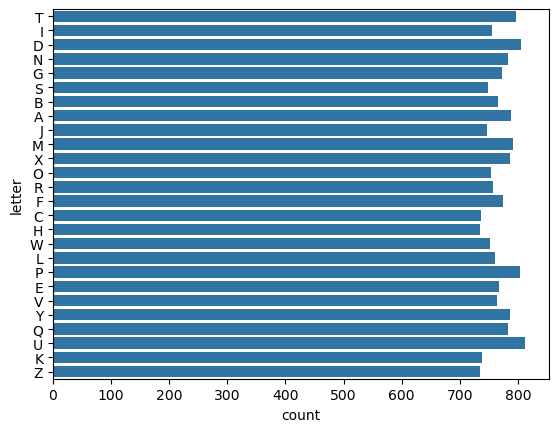

In [7]:
sns.countplot(y = y)

In [8]:
y.value_counts()

letter
U    813
D    805
P    803
T    796
M    792
A    789
X    787
Y    786
N    783
Q    783
F    775
G    773
E    768
B    766
V    764
L    761
R    758
I    755
O    753
W    752
S    748
J    747
K    739
C    736
H    734
Z    734
Name: count, dtype: int64

In [9]:
x.describe()

,xbox,ybox,width,height,onpix,xbar,ybar,x2bar,y2bar,xybar,x2ybar,xy2bar,xedge,xedgey,yedge,yedgex
count,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000
mean,4.023550,7.035500,5.121850,5.37245,3.505850,6.897600,7.500450,4.628600,5.178650,8.282050,6.45400,7.929000,3.046100,8.338850,3.691750,7.80120
std,1.913212,3.304555,2.014573,2.26139,2.190458,2.026035,2.325354,2.699968,2.380823,2.488475,2.63107,2.080619,2.332541,1.546722,2.567073,1.61747
min,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,3.000000,5.000000,4.000000,4.00000,2.000000,6.000000,6.000000,3.000000,4.000000,7.000000,5.00000,7.000000,1.000000,8.000000,2.000000,7.00000
50%,4.000000,7.000000,5.000000,6.00000,3.000000,7.000000,7.000000,4.000000,5.000000,8.000000,6.00000,8.000000,3.000000,8.000000,3.000000,8.00000
75%,5.000000,9.000000,6.000000,7.00000,5.000000,8.000000,9.000000,6.000000,7.000000,10.000000,8.00000,9.000000,4.000000,9.000000,5.000000,9.00000
max,15.000000,15.000000,15.000000,15.00000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.00000,15.000000,15.000000,15.000000,15.000000,15.00000


In [10]:
#cross validation
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

In [11]:
x_train.shape

(16000, 16)

In [12]:
x_test.shape

(4000, 16)

In [13]:
#build the model
from keras.models import Sequential
from keras.layers import Input, Dense

In [14]:
#create model object
model = Sequential()

#input layer
model.add(Input((16,)))

#hidden layer -1
model.add(Dense(32, activation='relu'))

#hidden layer -2

model.add(Dense(16, activation='relu'))

#output layer
model.add(Dense(26, activation='softmax'))

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │             544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 26)                  │             442 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,514 (5.91 KB)

 Trainable params: 1,514 (5.91 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
#one hot encoding 
x = ['A','C','C','B','A','C','A','B']

In [17]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
x_le = le.fit_transform(x)

from keras.utils import to_categorical
to_categorical(x_le)

array([[1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.]])

In [18]:
#separate the input and output variables
x = df.drop('letter',axis=1)#input data
y = df['letter']


#prepare the output variable
y_le = le.fit_transform(y)    #label encode
y_new = to_categorical(y_le)   #one hot encode


#cross validation
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y_new, test_size=0.2, random_state=0)

In [19]:
x_train.shape

(16000, 16)

In [20]:
y_train.shape

(16000, 26)

In [21]:
#compile the model
model.compile(loss = 'categorical_crossentropy', optimizer = 'adam',
              metrics = ['accuracy'])

In [22]:
#train the model
model.fit(x_train, y_train, epochs=20, batch_size=4)

Epoch 1/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 4s 760us/step - accuracy: 0.4629 - loss: 1.8279
Epoch 2/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 3s 759us/step - accuracy: 0.6853 - loss: 1.0892
Epoch 3/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 3s 829us/step - accuracy: 0.7333 - loss: 0.9079
Epoch 4/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 3s 789us/step - accuracy: 0.7594 - loss: 0.8094
Epoch 5/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 3s 813us/step - accuracy: 0.7704 - loss: 0.7505
Epoch 6/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 3s 812us/step - accuracy: 0.7816 - loss: 0.7111
Epoch 7/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7931 - loss: 0.6777  
Epoch 8/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 3s 865us/step - accuracy: 0.7949 - loss: 0.6591
Epoch 9/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 3s 761us/step - accuracy: 0.8036 - loss: 0.6326
Epoch 10/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 907s 227ms/step - accuracy: 0.8129 - loss: 0.6119 
Epoch 11/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 1426s 357ms/step - accuracy: 0.8167 - loss: 0.5978
Ep

In [23]:
#evaluate on testing
model.evaluate(x_test, y_test, batch_size=1)

4000/4000 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.8655 - loss: 0.4670


[0.46704909205436707, 0.8654999732971191]